# DSA4262 Assignment 1
## Mental Health Data Visualisation

### Introduction

**Suicide remains a major global public health concern** and is a leading cause of preventable mortality worldwide. While population-level trends are commonly used to assess national mental health outcomes, such **macro indicators can obscure critical high-risk transition periods** where targeted interventions may be most effective. As a result, relying solely on national averages risks overlooking **clinically actionable windows of vulnerability**.

In this assignment, I adopt a **progressive data visualisation narrative** to move from broad international suicide trends toward a **micro-level, clinically actionable focus on post-psychiatric-discharge risk**, a well-established period of elevated vulnerability in mental healthcare systems. By structuring the analysis from macro to micro to actionable, the visualisations are designed to support **evidence-informed intervention design** rather than descriptive reporting alone.

Two complementary datasets are used. The first is **World Bank suicide mortality data derived from WHO estimates**, which provides long-term, cross-country, population-level trends to establish the broader public health context. The second is **OECD Health Care Quality Indicators data on suicide within 30 days following psychiatric discharge**, which captures system-level performance in managing high-risk clinical transitions.

Together, these datasets enable the analysis to explicitly link **macro public health patterns** with **micro-level care pathway vulnerabilities**, and to identify **practical, targeted opportunities for improving mental health service delivery in a Singaporean context**.


## Plot 1: Macro Landscape of Suicide Mortality in High-Income Countries


In [1]:
# Data Loading 
import pandas as pd
import matplotlib.pyplot as plt

# Load World Bank suicide data (WHO estimates via World Bank)
wb = pd.read_csv("../data/API_SH.STA.SUIC.P5_DS2_en_csv_v2_1516.csv", skiprows=4)

wb.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Suicide mortality rate (per 100,000 population)",SH.STA.SUIC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Suicide mortality rate (per 100,000 population)",SH.STA.SUIC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,7.718408,7.670187,7.974624,8.046490,7.953714,8.353932,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Suicide mortality rate (per 100,000 population)",SH.STA.SUIC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,3.470000,3.560000,3.560000,3.530000,3.490000,3.600000,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Suicide mortality rate (per 100,000 population)",SH.STA.SUIC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,5.598274,5.557783,5.563167,5.543367,5.490407,5.764312,NaN,NaN,NaN,NaN
4,Angola,AGO,"Suicide mortality rate (per 100,000 population)",SH.STA.SUIC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,6.490000,6.470000,7.150000,7.520000,7.410000,8.110000,NaN,NaN,NaN,NaN


In [2]:
# Keep only recent years
year_cols = [str(y) for y in range(2000, 2024)]
cols = ["Country Name", "Country Code"] + year_cols

wb_recent = wb[cols]

# Melt to long format
wb_long = wb_recent.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="SuicideRate"
)

wb_long["Year"] = wb_long["Year"].astype(int)

wb_long.head()


,Country Name,Country Code,Year,SuicideRate
0,Aruba,ABW,2000,NaN
1,Africa Eastern and Southern,AFE,2000,7.821675
2,Afghanistan,AFG,2000,4.360000
3,Africa Western and Central,AFW,2000,5.663385
4,Angola,AGO,2000,9.120000


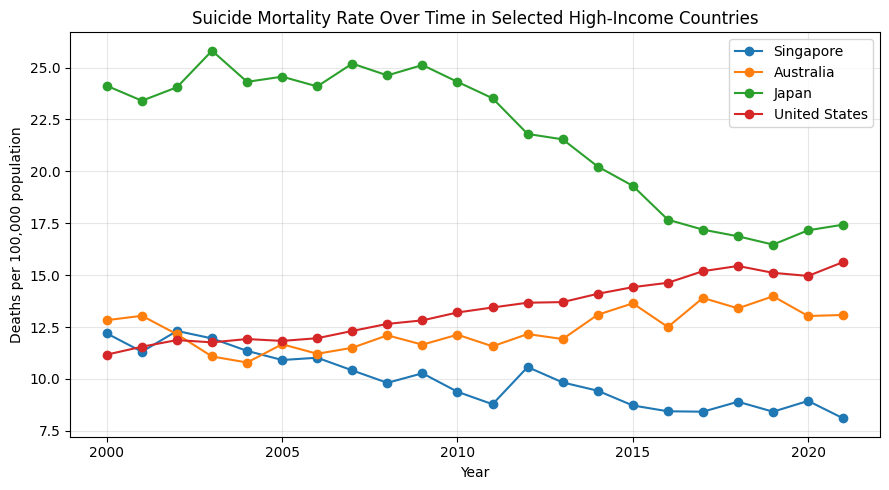

In [3]:
countries = ["Singapore", "Australia", "Japan", "United States"]

plot_df = wb_long[
    (wb_long["Country Name"].isin(countries)) &
    (wb_long["Year"] >= 2000) &
    (wb_long["Year"] <= 2021)
]

plt.figure(figsize=(9,5))

for c in countries:
    temp = plot_df[plot_df["Country Name"] == c].sort_values("Year")
    plt.plot(temp["Year"], temp["SuicideRate"], marker="o", label=c)

plt.title("Suicide Mortality Rate Over Time in Selected High-Income Countries")
plt.ylabel("Deaths per 100,000 population")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Motivation and Findings (Plot 1: Macro)

This macro-level plot presents long-term suicide mortality trends in selected high-income countries (Singapore, Japan, Australia, and the United States) using World Bank data derived from WHO estimates. The purpose of this visualisation is to establish suicide as a persistent public health challenge even in countries with advanced healthcare systems and high levels of economic development.

While Japan and Singapore show gradual declines over the past two decades, Australia and the United States exhibit increasing trends. This divergence demonstrates that economic prosperity and overall healthcare spending alone do not guarantee sustained reductions in suicide mortality. The findings motivate a shift away from purely macroeconomic explanations toward healthcare system design, social stressors, and mental health service continuity as key drivers of suicide risk.

By establishing that suicide remains a significant issue even in well-resourced settings, this plot provides the macro-level justification for examining more specific, system-level vulnerabilities in subsequent analyses.


### Limitation and Potential Misinterpretation

Suicide mortality data are subject to underreporting and variation in death certification practices across countries. Cultural stigma and differences in medico-legal classification may bias cross-country comparisons, particularly in Asian contexts. As a result, observed declines may partially reflect reporting practices rather than true reductions in suicidal behaviour.

In addition, population-level trends do not identify specific high-risk periods or care pathways where targeted interventions may be most effective. This limitation motivates the need for more intricate, clinically focused indicators, which are explored in the subsequent plots.


## Plot 2: Micro-Level Deep Dive into Post-Discharge Suicide Risk


In [4]:
# Load OECD mental healthcare data
oecd = pd.read_csv("../data/oecd_mental_healthcare.csv")
oecd.head()


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,DECIMALS,Decimals,OBS_STATUS,Observation status,OBS_STATUS2,Observation status 2,OBS_STATUS3,Observation status 3,UNIT_MULT,Unit multiplier
0,DATAFLOW,OECD.ELS.HD:DSD_HCQO@DF_MH(2.1),Mental healthcare,I,CAN,Canada,A,Annual,MORTSUMS,Suicide within 30 days after discharge among p...,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
1,DATAFLOW,OECD.ELS.HD:DSD_HCQO@DF_MH(2.1),Mental healthcare,I,CAN,Canada,A,Annual,MORTSUMS,Suicide within 30 days after discharge among p...,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
2,DATAFLOW,OECD.ELS.HD:DSD_HCQO@DF_MH(2.1),Mental healthcare,I,CAN,Canada,A,Annual,MORTSUMS,Suicide within 30 days after discharge among p...,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
3,DATAFLOW,OECD.ELS.HD:DSD_HCQO@DF_MH(2.1),Mental healthcare,I,CAN,Canada,A,Annual,MORTSUMS,Suicide within 30 days after discharge among p...,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
4,DATAFLOW,OECD.ELS.HD:DSD_HCQO@DF_MH(2.1),Mental healthcare,I,CAN,Canada,A,Annual,MORTSUMS,Suicide within 30 days after discharge among p...,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units


In [5]:
# Keep only post-discharge suicide indicator
micro = oecd[oecd["MEASURE"] == "MORTSUMS"]

micro[["Reference area", "TIME_PERIOD", "OBS_VALUE"]].head()


,Reference area,TIME_PERIOD,OBS_VALUE
0,Canada,2016,0.9
1,Canada,2017,0.8
2,Canada,2018,0.9
3,Canada,2019,0.8
4,Canada,2020,1.0


In [6]:
# Clean and aggregate OECD micro data
micro_clean = oecd[
    (oecd["MEASURE"] == "MORTSUMS") &
    (oecd["OBS_VALUE"].notna())
]

# Aggregate to one value per country-year (mean)
micro_agg = (
    micro_clean
    .groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)
    ["OBS_VALUE"]
    .mean()
)


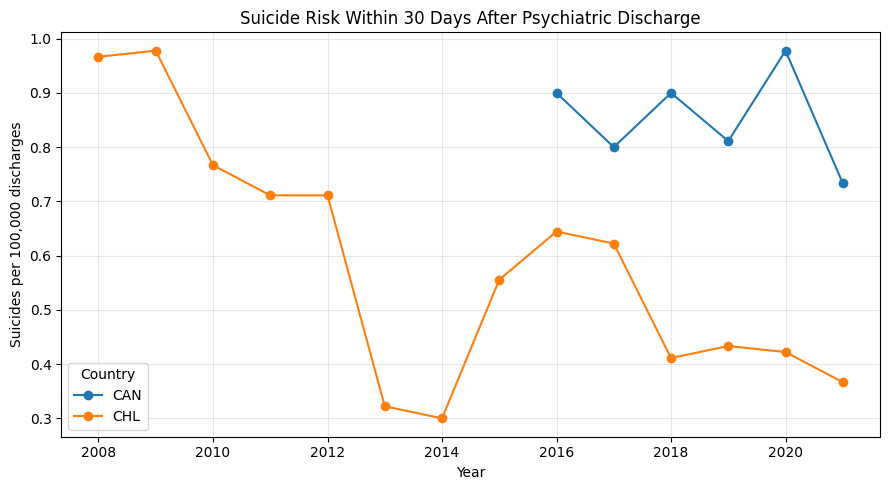

In [7]:
countries_micro = ["CAN", "CHL"]

micro_sel = micro_agg[micro_agg["REF_AREA"].isin(countries_micro)]

plt.figure(figsize=(9,5))

for c in countries_micro:
    temp = micro_sel[micro_sel["REF_AREA"] == c].sort_values("TIME_PERIOD")
    plt.plot(temp["TIME_PERIOD"], temp["OBS_VALUE"], marker="o", label=c)

plt.title("Suicide Risk Within 30 Days After Psychiatric Discharge")
plt.ylabel("Suicides per 100,000 discharges")
plt.xlabel("Year")
plt.legend(title="Country")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Motivation and Findings (Plot 2: Micro Deep Dive)

This micro-level plot examines suicide risk within 30 days following psychiatric discharge for selected OECD countries, using OECD Health Care Quality Indicators data. This indicator captures a clinically critical transition period when patients move from intensive inpatient care to community-based follow-up.

Despite overall population-level improvements observed in some countries in Plot 1, post-discharge suicide risk remains non-trivial and fluctuates over time. The persistence of elevated risk in this narrow window highlights continuity of care as a key vulnerability in mental health systems.

This plot reveals a nuance that is not visible in macro trends. Improvements in national suicide mortality do not necessarily translate into safer care transitions for high-risk patients. The findings indicate that system-level processes surrounding discharge and early follow-up play a critical role in shaping patient safety outcomes.


### Limitation and Potential Misinterpretation

OECD post-discharge indicators may be influenced by differences in hospital admission thresholds, discharge practices, and coding standards across countries. Higher rates may reflect more comprehensive reporting or a higher concentration of high-risk patients in inpatient care, rather than poorer care quality alone.

Therefore, these values should be interpreted as system-level signals of transition-of-care vulnerability rather than direct measures of individual clinician performance. The indicator is most appropriately used to identify high-risk care pathways that may benefit from targeted system-level intervention.


## Plot 3: Actionable Plot - International Benchmarks for Post-Discharge Suicide Risk


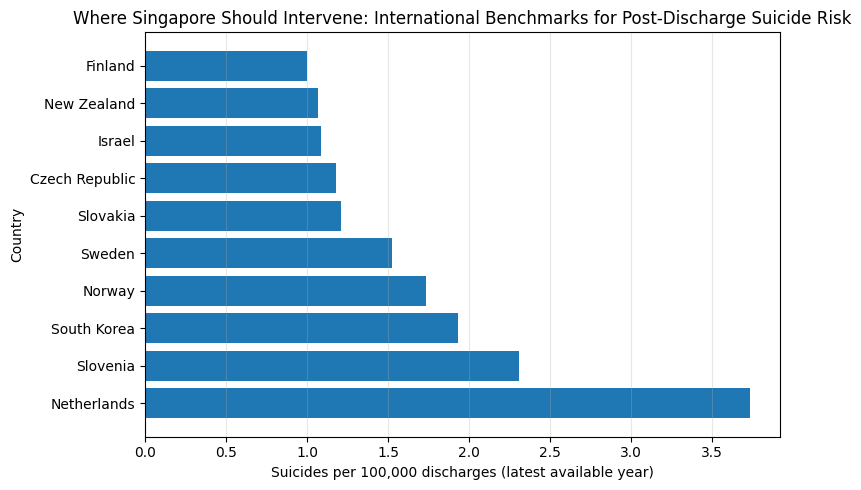

In [8]:
# Latest year per country (aggregated OECD data)
latest = (
    micro_agg
    .sort_values("TIME_PERIOD")
    .groupby("REF_AREA", as_index=False)
    .tail(1)
)

# Top 10 highest-risk countries (latest available year)
top10 = latest.sort_values("OBS_VALUE", ascending=False).head(10)

# Map country codes to names for clarity
country_map = {
    "NLD": "Netherlands",
    "NOR": "Norway",
    "KOR": "South Korea",
    "CZE": "Czech Republic",
    "SWE": "Sweden",
    "SVN": "Slovenia",
    "MLT": "Malta",
    "SVK": "Slovakia",
    "NZL": "New Zealand",
    "FIN": "Finland",
    "ISR": "Israel"
}

top10["Country"] = top10["REF_AREA"].map(country_map).fillna(top10["REF_AREA"])

# Plot
plt.figure(figsize=(8,5))
plt.barh(top10["Country"], top10["OBS_VALUE"])
plt.title("Where Singapore Should Intervene: International Benchmarks for Post-Discharge Suicide Risk")
plt.xlabel("Suicides per 100,000 discharges (latest available year)")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Motivation & Findings (Plot 3 — Actionable International Benchmark)

This plot benchmarks OECD countries by their latest available suicide risk within 30 days after psychiatric discharge. The substantial variation across otherwise comparable high-income healthcare systems demonstrates that elevated post-discharge suicide risk is not inevitable, but is strongly shaped by system-level factors such as discharge planning, continuity of care, and the intensity of early follow-up. The coexistence of both higher- and lower-performing systems suggests that outcomes during this vulnerable transition period are modifiable through healthcare system design and policy choices.

Although Singapore is not included in this OECD indicator, the international evidence directly informs local intervention design. The plot identifies the inpatient-to-community transition as a high-impact leverage point for suicide prevention. This supports the interpretation from Plot 2 that the immediate post-discharge period represents a clinically distinct risk window that is not captured by national-level suicide mortality trends alone. Together, these findings motivate a focus on targeted system interventions rather than relying solely on broad population-level mental health improvements.



## Limitation & Ethical Interpretation (Plot 3)

OECD post-discharge suicide indicators may not be fully comparable across countries due to differences in hospital admission thresholds, discharge practices, follow-up models, and coding standards. Higher observed rates may reflect more comprehensive identification and reporting of high-risk patients rather than poorer quality of care alone. As Singapore is not included in this dataset, this plot should not be interpreted as a direct assessment of Singapore’s current performance.

Instead, this figure serves as an international benchmark to highlight a universally recognised high-risk transition period and to inform the design of locally appropriate interventions. The absence of publicly available Singapore-specific post-discharge outcome indicators also reflects a limitation in local data transparency for evaluating continuity of mental healthcare and system-level accountability.



## Proposed Singapore Intervention (Policy-Level, Concrete, Measurable)

**Target window:** First 30 days post-discharge  
**Intervention logic:** Time-bounded, high-risk, system-controllable  
**Impact goal:** Reduce suicide risk during the most vulnerable care transition period

**Proposed national discharge protocol for psychiatric inpatients:**

- Mandatory follow-up contact within **72 hours** of discharge  
- Scheduled outpatient psychiatric review within **7 days**  
- Structured safety planning completed prior to discharge  
- Centralised national monitoring dashboard for missed follow-ups  
- Automatic escalation pathway for non-attendance or loss to follow-up  

This intervention directly targets a clearly defined and evidence-supported vulnerability window, enabling measurable system accountability and focused resource deployment. By strengthening continuity of care immediately after discharge, Singapore can address a high-impact leverage point for suicide prevention that is not visible in aggregate population mortality statistics alone.
